In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import modules.loaddata
import modules.loadroot
import importlib

# Load data and plot histogram
Change where the events file is loaded from

In [2]:
importlib.reload(modules.loadroot)
pure_lfg = modules.loadroot.load_events_file("./data/comparison/pure_lfg.root")
ab_initio_no_bind = modules.loadroot.load_events_file("./data/comparison/ab_initio_no_bind.root")
# ab_initio_with_bind = modules.loadroot.load_events_file("./data/comparison/ab_initio_with_bind.root")
baseline = modules.loadroot.load_events_file("./data/qel_baseline.root") 

In [19]:
def load_t2k_bins(filename): # costhetamin, costhetamax, mommin, mommax
    with open(filename, "r") as f:
        lines = f.readlines()
    bins = []
    for line in lines[1:]: # Skip header
        fields = list(filter(None, line.strip().split(" ")))
        bins.append([float(x) for x in fields])
    print(bins)
    return bins

t2k_bins = load_t2k_bins("./data/T2KDataRelease/Binning.txt")

def load_t2k_results(filename): # number, o16xsec, c12xsec, o16 uncertainty, c12 uncertainty, o16/c12 ratio, o16/c12 uncertainty
    with open(filename, "r") as f:
        lines = f.readlines()
    results = []
    for line in lines:
        fields = list(filter(None, line.strip().split(" ")))
        results.append([float(x) for x in fields])
    print(results)
    return results

t2k_results = load_t2k_results("./data/T2KDataRelease/cc0pi_xsec_O-C-ratio_reg.txt")

[[-1.0, 0.0, 0.0, 30.0], [0.0, 0.6, 0.0, 0.35], [0.0, 0.6, 0.35, 0.45], [0.0, 0.6, 0.45, 0.55], [0.0, 0.6, 0.55, 30.0], [0.6, 0.75, 0.0, 0.35], [0.6, 0.75, 0.35, 0.45], [0.6, 0.75, 0.45, 0.55], [0.6, 0.75, 0.55, 0.7], [0.6, 0.75, 0.7, 30.0], [0.75, 0.86, 0.0, 0.4], [0.75, 0.86, 0.4, 0.5], [0.75, 0.86, 0.5, 0.6], [0.75, 0.86, 0.6, 0.7], [0.75, 0.86, 0.7, 0.85], [0.75, 0.86, 0.85, 30.0], [0.86, 0.93, 0.0, 0.5], [0.86, 0.93, 0.5, 0.6], [0.86, 0.93, 0.6, 0.7], [0.86, 0.93, 0.7, 0.9], [0.86, 0.93, 0.9, 30.0], [0.93, 1.0, 0.0, 0.5], [0.93, 1.0, 0.5, 0.6], [0.93, 1.0, 0.6, 0.8], [0.93, 1.0, 0.8, 1.0], [0.93, 1.0, 1.0, 1.5], [0.93, 1.0, 1.5, 2.5], [0.93, 1.0, 2.5, 4.0], [0.93, 1.0, 4.0, 30.0]]
[[0.0, 0.032, 0.009, 0.035, 0.008, 0.912, 0.215], [1.0, 3.199, 0.799, 2.288, 0.401, 1.423, 0.267], [2.0, 9.318, 1.564, 7.117, 1.031, 1.321, 0.161], [3.0, 5.323, 1.092, 4.482, 0.724, 1.204, 0.22], [4.0, 0.008, 0.002, 0.008, 0.002, 1.108, 0.285], [5.0, 1.811, 0.587, 1.931, 0.395, 0.964, 0.346], [6.0, 10.32

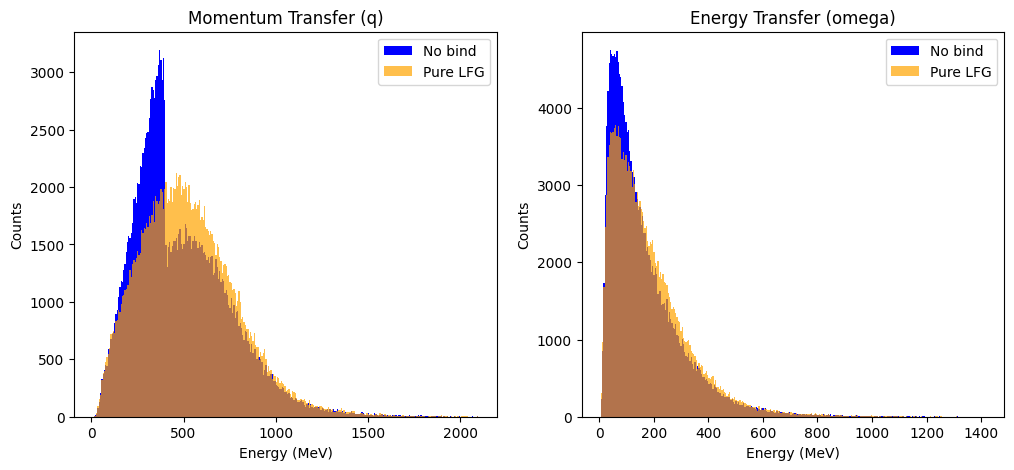

In [4]:
def plot_dsitributions(data1, data2, label1, label2):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    bins = np.histogram(np.hstack([data1["q_vals"], data2["q_vals"]]), bins=300)[1]
    ax[0].hist(data1["q_vals"], bins=bins, alpha=1, label=label1, color="blue")
    ax[0].hist(data2["q_vals"], bins=bins, alpha=0.7, label=label2, color="orange")

    bins = np.histogram(np.hstack([data1["omega_vals"], data2["omega_vals"]]), bins=300)[1]
    ax[1].hist(data1["omega_vals"], bins=bins, alpha=1, label=label1, color="blue")
    ax[1].hist(data2["omega_vals"], bins=bins, alpha=0.7, label=label2, color="orange")

    ax[0].legend()
    ax[1].legend()

    ax[0].set_xlabel("Energy (MeV)")
    ax[1].set_xlabel("Energy (MeV)")

    ax[0].set_ylabel("Counts")
    ax[1].set_ylabel("Counts")

    ax[0].set_title("Momentum Transfer (q)")
    ax[1].set_title("Energy Transfer (omega)")
plot_dsitributions(ab_initio_no_bind, pure_lfg, "No bind", "Pure LFG")

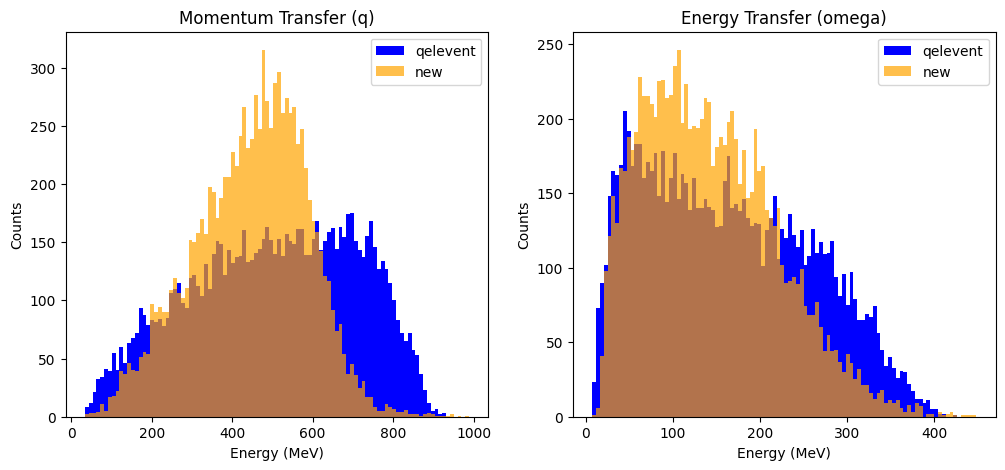

In [ ]:
# mom_ins, mom_outs, q_vals, omega_vals = modules.loadroot.load_events_file("../nuwro/eventsout.root")
mom_ins, mom_outs, q_vals, omega_vals, weights = modules.loadroot.load_events_file("../nuwro/eventsout.root")
# importlib.reload(modules.loadroot)
# importlib.reload(modules.loaddata)

e

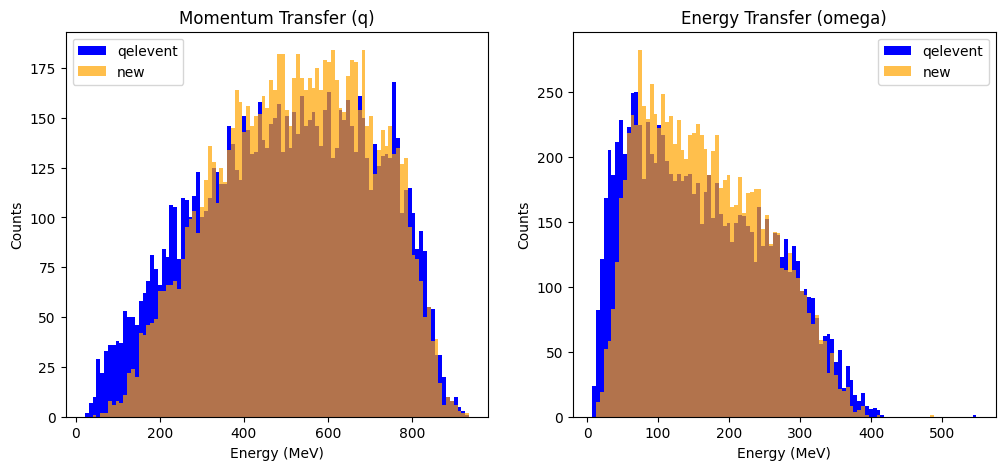

In [178]:

# mom_ins, mom_outs, q_vals, omega_vals = modules.loadroot.load_events_file("../nuwro/eventsout.root")
mom_ins_2, mom_outs_2, q_vals_2, omega_vals_2, weights_2 = modules.loadroot.load_events_file("../nuwro/eventsout.root")
# importlib.reload(modules.loadroot)
# importlib.reload(modules.loaddata)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

bins = np.histogram(np.hstack([q_vals_qel, q_vals_2]), bins=100)[1]
ax[0].hist(q_vals_qel, bins=bins, alpha=1, label="qelevent", color="blue")
ax[0].hist(q_vals_2, bins=bins, alpha=0.7, label="new", color="orange")

bins = np.histogram(np.hstack([omega_vals_qel, omega_vals_2]), bins=100)[1]
ax[1].hist(omega_vals_qel, bins=bins, alpha=1, label="qelevent", color="blue")
ax[1].hist(omega_vals_2, bins=bins, alpha=0.7, label="new", color="orange")

ax[0].legend()
ax[1].legend()

ax[0].set_xlabel("Energy (MeV)")
ax[1].set_xlabel("Energy (MeV)")

ax[0].set_ylabel("Counts")
ax[1].set_ylabel("Counts")

ax[0].set_title("Momentum Transfer (q)")
ax[1].set_title("Energy Transfer (omega)")
None

# $q/\omega$ scatterplot

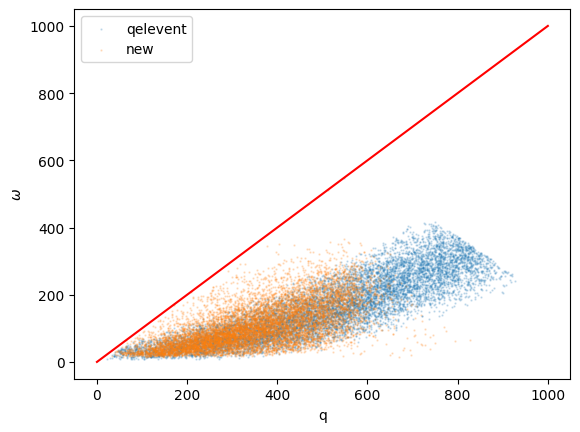

In [5]:
size = 0.5
alpha = 0.2
plt.Figure(dpi=600)
plt.scatter(q_vals_qel, omega_vals_qel, s=size, alpha=alpha, label="qelevent")
plt.scatter(q_vals, omega_vals, s=size, alpha=alpha, label="new")
plt.plot([0, 1000], [0,1000], color="red")
plt.ylabel("$\\omega$")
plt.xlabel("q")
plt.legend()

# $q$ slice comparison to expected response

In [6]:
# Load lfg data, create interpolator
lfg_q, lfg_data = modules.loaddata.load_response_functions("./data/lfg_week4_data/", "responses_C12_CC_LFG")
funcs = modules.loaddata.build_spectral_interpolator(lfg_q, lfg_data)
t2k_bins, t2k_vals = modules.loaddata.load_t2k("data/t2k/t2kflux_2020_plus250kA_nominal_nd280.txt")


In [7]:
MeV = 1
GeV = 1000 * MeV
sek = 1 / (6.58211889 * 1E-22 * MeV)
metr = sek / 299792458
meter = metr
millimeter = 0.001 * meter
centimeter = 10 * millimeter
centimeter2 = centimeter ** 2
cm2 = centimeter2
G = 1.16639 * 1E-5 / (GeV * GeV)

def q_to_costheta(q, w, eps):
    # q^2 = k^2 + k'^2 - 2kk'cos(theta)
    # cos(theta) = (k^2 + k'^2 - q^2) / (2kk')
    k = eps
    kp = eps - w
    cos_theta = (k**2 + kp**2 - q**2) / (2 * k * kp)
    return cos_theta

Pure LFG: 37031 events in costheta range [-1, 0]
Counts: [37031]
Ab Initio (No Bind): 27932 events in costheta range [-1, 0]
Counts: [27932]
Pure LFG: 54479 events in costheta range [0, 0.6]
Counts: [17635 18498 11492  6854]
Ab Initio (No Bind): 42475 events in costheta range [0, 0.6]
Counts: [10812 15844 10070  5749]
Pure LFG: 24428 events in costheta range [0.6, 0.75]
Counts: [3011 5569 6736 5823 3289]
Ab Initio (No Bind): 19761 events in costheta range [0.6, 0.75]
Counts: [1274 4549 5751 5255 2932]
Pure LFG: 24175 events in costheta range [0.75, 0.86]
Counts: [3238 5022 5589 4110 3219 2997]
Ab Initio (No Bind): 19599 events in costheta range [0.75, 0.86]
Counts: [1712 4010 4883 3792 2677 2525]
Pure LFG: 19948 events in costheta range [0.86, 0.93]
Counts: [4895 4010 3613 3901 3529]
Ab Initio (No Bind): 15978 events in costheta range [0.86, 0.93]
Counts: [3185 3346 3213 3311 2923]
Pure LFG: 25547 events in costheta range [0.93, 1]
Counts: [4322 4053 7536 3902 4899  835    0    0]
Ab I

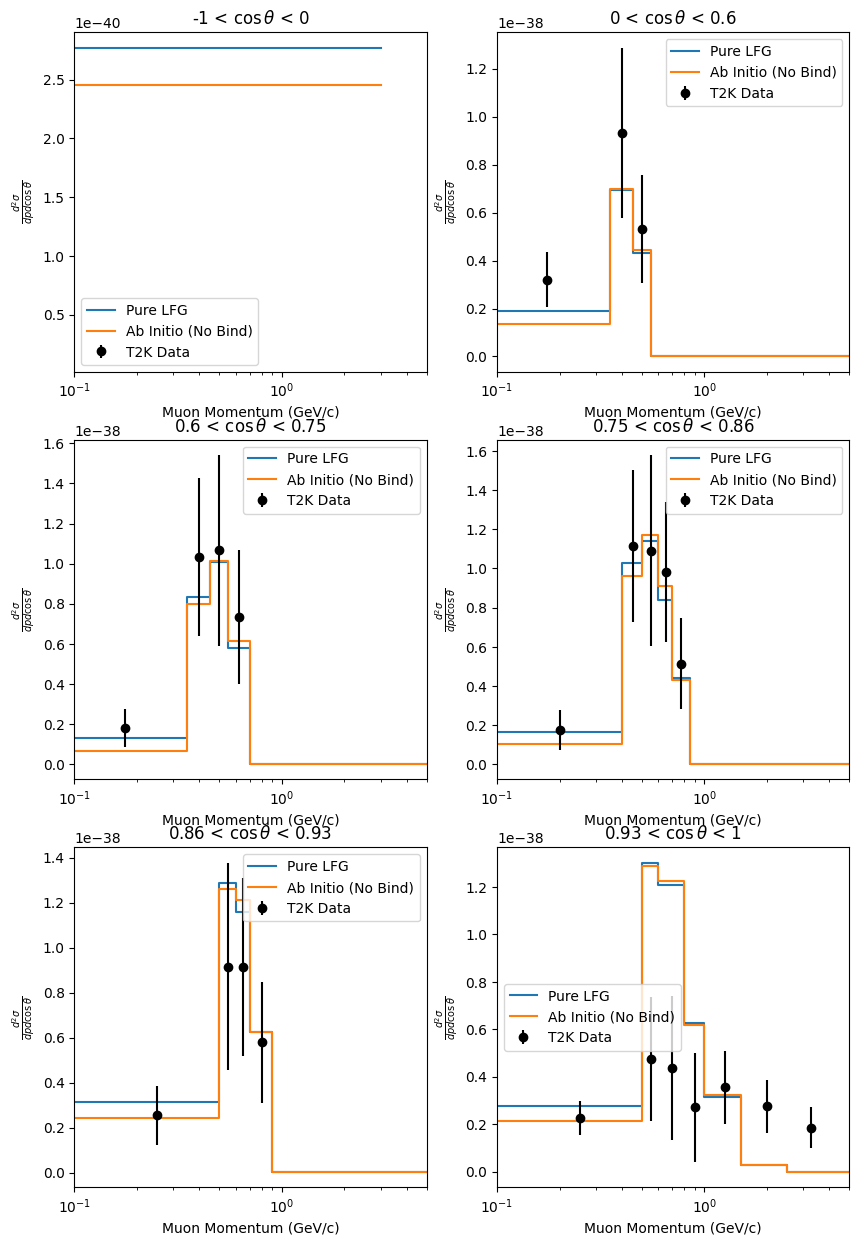

In [27]:
def bar_to_line(bins, counts, widths):
    x = np.empty(2 * len(counts))
    x[0::2] = bins[:-1]
    x[1::2] = bins[1:]
    y = np.empty_like(x)
    y[0::2] = counts
    y[1::2] = counts
    return x, y

def calc_xsec_from_events(events, costhetalims, muon_momentum_bins, label, axs):
    qvals = np.array(events["q_vals"])
    wvals = np.array(events["omega_vals"])
    muon_mom_outs = events["mom_outs"]
    muon_momentums = np.linalg.norm(muon_mom_outs[:,1:], axis=1)
    eps = np.array(events["mom_ins"])[:,0]
    avgweight = np.array(events["weights"])[0]

    # costhetas = q_to_costheta(qvals, wvals, eps)
    costhetas = muon_mom_outs[:,3] / muon_momentums
    # plt.plot(costhetas, costhetas2, 'o')
    # print(costhetas)
    # print(costhetas2)
    mask = (costhetas > costhetalims[0]) & (costhetas < costhetalims[1])
    nonzero_counts = np.sum(mask)
    print(f"{label}: {nonzero_counts} events in costheta range {costhetalims}")
    counts, bins = np.histogram(muon_momentums[mask], bins=muon_momentum_bins)
    print(f"Counts: {counts}")
    
    # t2k_data_x = []
    # t2k_data_y = []
    # t2k_data_y_err = []

    # for (i, t2kbin) in enumerate(t2k_bins):
    #     if np.isclose(costhetalims, t2kbin[:2]).all():
    #         t2k_data_x.append((t2kbin[2] + t2kbin[3]) / 2)
    #         t2k_data_y.append(t2k_results[i][1] * 1e-39)
    #         t2k_data_y_err.append(t2k_results[i][3] * 1e-39)
    
    # axs.scatter(t2k_data_x, t2k_data_y, label="T2K Data", color="black")
    
    dcostheta = costhetalims[1] - costhetalims[0]
    dmom = muon_momentum_bins[1:] - muon_momentum_bins[:-1]

    xsec = avgweight * counts / len(qvals) / (dmom * dcostheta)*1000 # The paper xsec is in /GeV
    
    # plt.bar(bins[:-1]/1000, xsec, width=dmom/1000, align="edge", alpha=0.5, label=label)
    x, y = bar_to_line(bins/1000, xsec, dmom/1000)
    axs.plot(x, y, label=label)

def plot_xsec_from_t2k_data(costhetalims, muon_momentum_bins, axs):
    t2k_data_x = []
    t2k_data_y = []
    t2k_data_y_err = []

    for (i, t2kbin) in enumerate(t2k_bins):
        if np.isclose(costhetalims, t2kbin[:2]).all(): # We are assuming the bins are in momentum ascending order
            t2k_data_x.append((t2kbin[2] + t2kbin[3]) / 2)
            t2k_data_y.append(t2k_results[i][1] * 1e-39)
            t2k_data_y_err.append(t2k_results[i][3] * 0.5e-39)
    
    axs.errorbar(t2k_data_x, t2k_data_y, yerr=t2k_data_y_err, fmt='o', label="T2K Data", color="black")

costhetalimits = [
    [-1, 0],
    [0, 0.6],
    [0.6, 0.75],
    [0.75, 0.86],
    [0.86, 0.93],
    [0.93, 1]
]

bins = [
    [0, 3000],
    [0, 350, 450, 550, 30000],
    [0, 350, 450, 550, 700, 30000],
    [0, 400, 500, 600, 700, 850, 30000],
    [0, 500, 600, 700, 900, 30000],
    [0, 500, 600, 800, 1000, 1500, 2500, 4000, 30000]
]

idx = 3

# 2x3 figure grid
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
axes = axes.flatten()

for i in range(6):
    calc_xsec_from_events(pure_lfg, costhetalimits[i], np.array(bins[i]), "Pure LFG", axes[i])
    calc_xsec_from_events(ab_initio_no_bind, costhetalimits[i], np.array(bins[i]), "Ab Initio (No Bind)", axes[i])
    plot_xsec_from_t2k_data(costhetalimits[i], np.array(bins[i]), axes[i])
    axes[i].set_xscale("log")
    axes[i].set_xlim(0.1, 5)
    # axes[i].set_xlim(-1, 1)
    axes[i].set_ylabel("$\\frac{d^2 \\sigma}{dp d \\cos \\theta}$")
    axes[i].set_xlabel("Muon Momentum (GeV/c)")
    axes[i].set_title(f"{costhetalimits[i][0]} < $\\cos\\theta$ < {costhetalimits[i][1]}")
    axes[i].legend()
# calc_xsec_from_events(ab_initio_with_bind, costhetalimits[i], np.array(bins[i]), "Ab Initio (With Bind)", axes[i])

/tmp/ipykernel_79694/1166750139.py:14: RuntimeWarning: invalid value encountered in sqrt
  k_prim = np.sqrt(eps_prim**2 - m_l**2)


Text(0, 0.5, 'Differential Cross Section (cm$^2$ / MeV)')

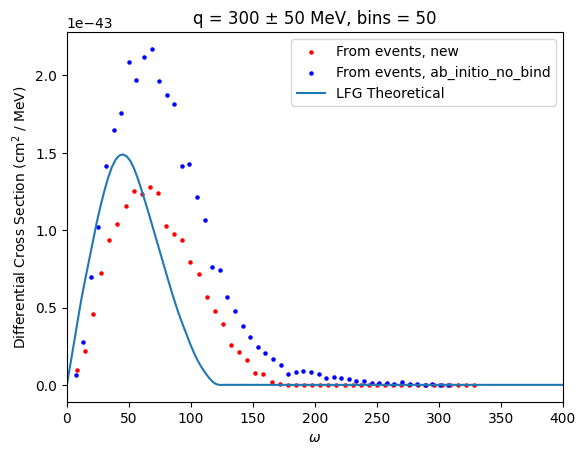

In [12]:
target_q = 300 # q for which to plot
q_delta = 50 # how wide the q slice should be
n_nucleons = 12 # Carbon nucleons

# Mathematical differential cross section calculation ------
eps = 600 # Beam energy
#muon mass
m_l = 105.66

# omega = test_x
omega = np.linspace(0, 600, 200)
eps_prim = eps - omega
k = eps
k_prim = np.sqrt(eps_prim**2 - m_l**2)

Q_sq = target_q**2 - omega**2

costheta = (k**2 + k_prim**2 - target_q**2) / (2 * k * k_prim)
# costheta = np.arccos(temp)
# costheta = np.nan_to_num(costheta)


v00 = 2 * eps * eps_prim * ( 1 + k_prim/eps_prim * costheta )
vzz = omega**2 / target_q**2 * (m_l ** 2 + v00) + m_l**2 / target_q**2 * (m_l**2 + 2 * omega * (eps + eps_prim) + target_q**2)
v0z = omega / target_q * (m_l**2 + v00) + m_l**2 / target_q * (eps + eps_prim)
vxx = Q_sq + Q_sq * (m_l**2 + v00) / (2 * target_q**2) - m_l**2 / target_q**2 * (m_l**2 / 2 + omega * (eps + eps_prim))
vxy = Q_sq * (eps + eps_prim) / target_q - m_l**2 * omega / target_q
# r00 r0z rzz rxx rxy
coeffs = np.array([v00, -v0z, vzz, vxx, -vxy])

nrf_vals = np.array([
    funcs[0]((target_q, omega)),
    funcs[1]((target_q, omega)),
    funcs[2]((target_q, omega)),
    funcs[3]((target_q, omega)),
    funcs[4]((target_q, omega)),
])
cross_section = np.nan_to_num(np.sum(nrf_vals * coeffs, axis=0)) * G**2 / (8 * np.pi**2) * (k_prim) / (eps) / cm2

# q^2 = k^2 + k'^2 - 2kk'cos(theta)
# 2q dq = -2kk' d cos(theta)
# d cos(theta)/dq = -q / (kk')

jakobian = target_q / (k * k_prim)
cross_section *= jakobian

# Differential cross section from events ------
bincount = 50

def plot_xsec_from_events(data, label, colour):
    mask = np.abs(data["q_vals"] - target_q) < q_delta
    # mask = np.array([qvals > target_q and qvals < target_q + q_delta for qvals in qvals])
    counts, bins = np.histogram(data["omega_vals"][mask], bins=bincount)
    
    dq = q_delta * 1
    dw = bins[1] - bins[0]

    xsec = data["weights"][0] * counts / len(data["q_vals"]) / (dw * dq) 
    # eps_prim_bins = eps - bins[:-1]
    # k_prim_bins = np.sqrt(eps_prim_bins**2 - m_l**2)
    # xsec *= target_q * (k * k_prim_bins)

    plt.scatter(bins[:-1], xsec, label=f"From events, {label}", color=colour, s=5)

plot_xsec_from_events(pure_lfg, "new", "red")
plot_xsec_from_events(ab_initio_no_bind, "ab_initio_no_bind", "blue")

plt.Figure(figsize=(10,6), dpi=300)


# plt.plot(omega + 34, cross_section / (np.max(cross_section)), label="In python")
plt.plot(omega, cross_section, label="LFG Theoretical")

plt.title(f"q = {target_q} ± {q_delta} MeV, bins = {bincount}")
plt.legend()
plt.xlim(0, 400)
plt.xlabel("$\\omega$")
plt.ylabel("Differential Cross Section (cm$^2$ / MeV)")
# plt.ylim(-0.01, 0.01)

# NuWro T2K Beam profile

In [9]:
import scipy.interpolate
stepsize = 10
coordx = []
coordy = []
for i in range(len(t2k_bins)):
    xcoord = (t2k_bins[i][0] + t2k_bins[i][1]) / 2
    if xcoord > 1500:
        break
    coordx.append(xcoord)
    coordy.append(t2k_vals[i])

xpoints = np.arange(final_min, final_max, stepsize)

ypoints = scipy.interpolate.CubicSpline(coordx, coordy)(xpoints)


datax = []
datay = []
for x, y in zip(t2k_bins, t2k_vals):
    if x[0] > 1500:
        break
    datax.append((x[0]))
    datax.append((x[1]))
    datay.append(y)
    datay.append(y)

plt.figure(figsize=(20,12))
plt.plot(datax, datay / np.max(datay), label="Flux Data", color="black", drawstyle="steps-post", alpha=0.4)
plt.bar(xpoints, ypoints / np.max(ypoints), width=stepsize, label="Beam profile", color="orange")
plt.xlim(0, 1500)
plt.xlabel("Energy (MeV)")
plt.ylabel("Histogram Value (Normalized)")
plt.title("T2K Beam Profile")
plt.legend()

bins = ""
for y in ypoints:
    bins += f"{y/np.max(ypoints)} "

print(f"{np.min(xpoints)} {np.max(xpoints)} {bins}")

NameError: name 'final_min' is not defined

In [17]:
vals = []
vals_qel = []
with open("../nuwro/weights.txt", "r") as f:
    lines = f.readlines()
    for line in lines:
        vals.append(float(line.strip()))
with open("../nuwro/weights_qel.txt", "r") as f:
    lines = f.readlines()
    for line in lines:
        vals_qel.append(float(line.strip()))

vals = np.array(vals)
vals_qel = np.array(vals_qel)
print(np.average(vals), np.std(vals))
print(np.average(vals_qel), np.std(vals_qel))

2.332743263312816e-38 7.844208838953706e-38
4.475129359943338e-39 5.2612451902188116e-39
